## OCR Region Inspection

As part of the knowledge-base demo, we first inspect a representative BYTE magazine page to verify that the **layout-aware OCR pipeline is identifying distinct text regions** before evaluating the extracted text.

The sample page is taken from the **June 1985 BYTE issue** and contains multiple columns, headings, advertisements, and product descriptions. We load the page image together with the corresponding OCR output and filter the detected regions using the page ID. This lets us verify:

* how many regions DocLayout-YOLO detected on the page;
* whether the detected regions correspond to meaningful page content; and
* the text extracted from each detected region.

The region-level inspection provides a visual and textual sanity check before using the OCR output for the subsequent **retrieval demonstration**.


Total OCR regions in issue: 12149
Sample page size: (1241, 1613)


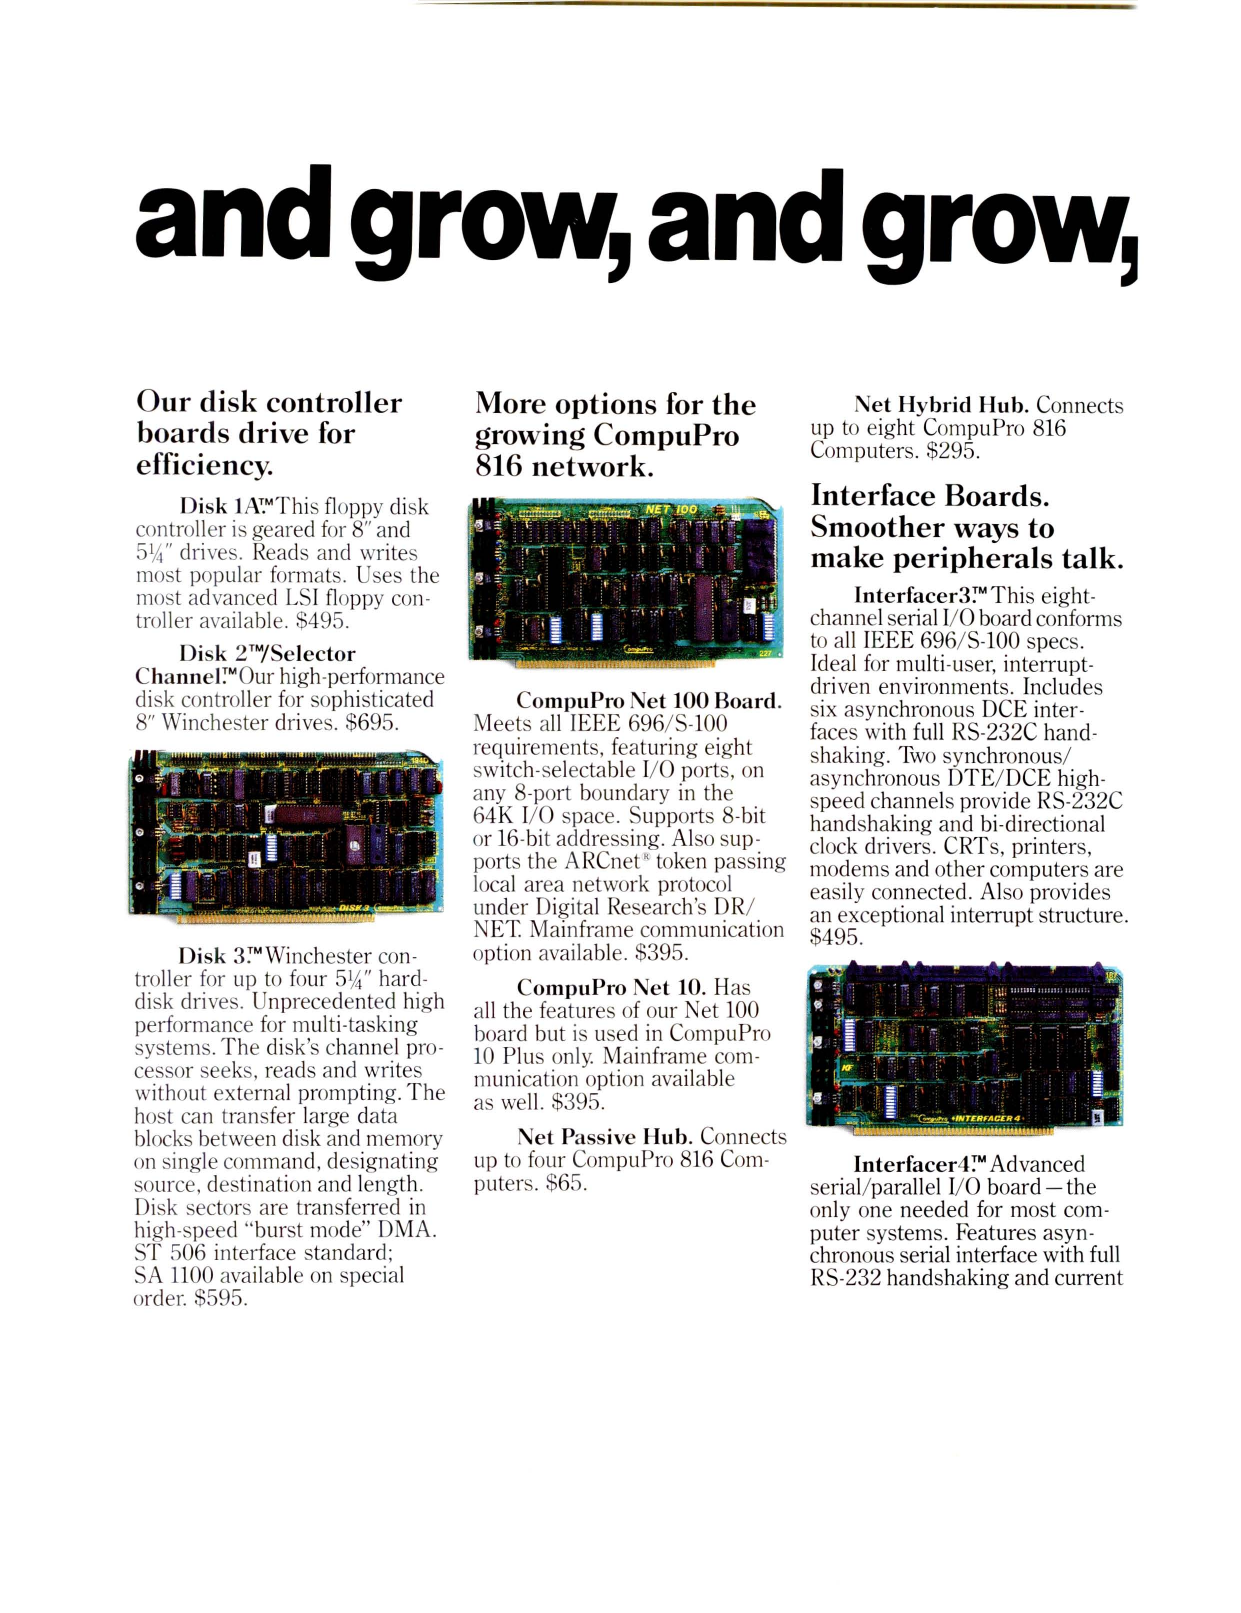


OCR regions belonging to page 40: 19
 1. 834 | text='and grow, and grow,'
 2. 835 | text='Our disk controller boards drive for efficiency.'
 3. 836 | text='Disk 1A: This floppy disk controller is geared for 8" and 51/4" drives. Reads an'
 4. 837 | text='Disk 2™/Selector Channel! Our high-performance disk controller for sophisticated'
 5. 838 | text='The text in the image appears to be a mix of different colors and patterns, maki'
 6. 839 | text='Disk 3: "Winchester controller for up to four 51/4" hard-disk drives. Unpreceden'
 7. 840 | text='More options for the growing CompuPro 816 network.'
 8. 841 | text='More options for the growing CompuPro 816 network.'
 9. 842 | text='MET 100'
10. 843 | text='CompuPro Net 100 Board'
11. 844 | text='CompareNet I/O Board Meets all IEEE 696/S-100 requirements, featuring eight swit'
12. 845 | text='CompuPro Net 10. Has all the features of our Net 100 board but is used in CompuP'
13. 846 | text='Net Passive Hub. Connects up to four CompuPro 816 Comp

In [38]:
# IMPLEMENT: run OCR quality + one retrieval, end to end

import json
from pathlib import Path
from IPython.display import display
from PIL import Image

OCR_FILE = Path("../data/interim/ocr/byte-magazine-1985-06.txt")
IMAGE_FILE = Path("../data/interim/pages/1985_06_BYTE_10-06_Programming_Techniques/page_0040.png")

# Load OCR output
with OCR_FILE.open("r", encoding="utf-8") as f:
    ocr_chunks = json.load(f)

print(f"Total OCR regions in issue: {len(ocr_chunks)}")

# Load sample page
image = Image.open(IMAGE_FILE)

print(f"Sample page size: {image.size}")
display(image)

# Find OCR regions belonging to page 40
PAGE_ID = "1985_06_BYTE_10-06_Programming_Techniques_p0040"

page_regions = [
    chunk for chunk in ocr_chunks
    if PAGE_ID in chunk.get("page_ids", [])
]

print(f"\nOCR regions belonging to page 40: {len(page_regions)}")

for i, region in enumerate(page_regions):
    print(
        f"{i + 1:2d}. "
        f"{region['id'][-3:]} | "
        f"text={region['text'][:80]!r}"
    )

## OCR Quality Evaluation

To quantify the quality of the OCR output, we evaluate it against a **manually transcribed ground-truth page** from the held-out `labels.jsonl` set. For this demonstration, we use **one labelled BYTE page** rather than the full held-out set.

The evaluation:

* retrieves the ground-truth transcription for the selected page;
* collects all OCR regions detected for the same page;
* concatenates the region-level OCR output in its pipeline order;
* normalizes whitespace so differences in line breaks and region boundaries do not artificially affect the measurement; and
* reports **Character Error Rate (CER)** and **Word Error Rate (WER)**.

This gives us a quantitative measurement of OCR quality on a real labelled sample while keeping the evaluation separate from the pipeline's large-corpus, pretrained-only processing.


In [39]:
import json
import re
from pathlib import Path
from jiwer import cer, wer

# ============================================================
# OCR QUALITY — ONE LABELLED PAGE
# ============================================================

OCR_FILE = Path(
    "../data/interim/ocr/byte-magazine-1975-09.txt"
)

LABELS_FILE = Path(
    "../grading_kit/labels.jsonl"
)

TARGET_PAGE = (
    "1975_09_BYTE_00-01_The_Worlds_Greatest_Toy_p0020"
)

# ------------------------------------------------------------
# 1. Load the ground-truth label
# ------------------------------------------------------------

reference_text = None

with LABELS_FILE.open("r", encoding="utf-8") as f:

    for line in f:

        line = line.strip()

        if not line:
            continue

        item = json.loads(line)

        if item.get("page_id") == TARGET_PAGE:
            reference_text = item["text"]
            break

if reference_text is None:
    raise ValueError(
        f"❌ Ground-truth label not found for {TARGET_PAGE}"
    )

# ------------------------------------------------------------
# 2. Load OCR output
# ------------------------------------------------------------

with OCR_FILE.open("r", encoding="utf-8") as f:
    ocr_chunks = json.load(f)

# ------------------------------------------------------------
# 3. Extract OCR regions belonging to this page
# ------------------------------------------------------------

page_chunks = [
    chunk
    for chunk in ocr_chunks
    if TARGET_PAGE in chunk.get("page_ids", [])
]

if not page_chunks:
    raise ValueError(
        f"❌ No OCR regions found for {TARGET_PAGE}"
    )

# Preserve the order of OCR regions in the OCR output
ocr_text = "\n".join(
    chunk.get("text", "")
    for chunk in page_chunks
)

# ------------------------------------------------------------
# 4. Normalize whitespace
# ------------------------------------------------------------
# Ground-truth labels use line breaks while OCR is region-based.
# We collapse consecutive whitespace so CER/WER measures text
# recognition rather than differences in line/region formatting.

def normalize_text(text):
    return re.sub(r"\s+", " ", text).strip()


reference_normalized = normalize_text(reference_text)
ocr_normalized = normalize_text(ocr_text)

# ------------------------------------------------------------
# 5. Calculate CER and WER
# ------------------------------------------------------------

page_cer = cer(
    reference_normalized,
    ocr_normalized
)

page_wer = wer(
    reference_normalized,
    ocr_normalized
)

# ------------------------------------------------------------
# 6. Display results
# ------------------------------------------------------------

print("=" * 70)
print("OCR QUALITY EVALUATION")
print("=" * 70)

print(f"Sample size     : 1 labelled page")
print(f"Page            : {TARGET_PAGE}")
print(f"OCR regions     : {len(page_chunks)}")
print(f"Reference chars : {len(reference_normalized)}")
print(f"OCR chars       : {len(ocr_normalized)}")
print(f"CER             : {page_cer:.2%}")
print(f"WER             : {page_wer:.2%}")

print("=" * 70)

OCR QUALITY EVALUATION
Sample size     : 1 labelled page
Page            : 1975_09_BYTE_00-01_The_Worlds_Greatest_Toy_p0020
OCR regions     : 20
Reference chars : 5231
OCR chars       : 4531
CER             : 20.02%
WER             : 20.89%


### CER/WER Interpretation

* **Layout-detection threshold:** We selected a DocLayout-YOLO `score_thr` of **0.25** after testing different thresholds on representative BYTE pages.

* **Why 0.25:** The threshold was chosen to prioritize **text-region recall** and **information preservation**. Increasing the threshold reduced some duplicate/overlapping detections, but also caused some genuine text regions to be missed.

* **Why missing regions matter:** For a retrieval system, **losing an entire text region is more harmful** because the missing information cannot later be retrieved or used as evidence.

* **Effect of the lower threshold:** At `0.25`, some regions may be **detected more than once**. Since OCR is performed region-by-region and the outputs are subsequently concatenated, these duplicate detections introduce repeated text.

* **Effect on CER/WER:** When the concatenated OCR output is compared with the single ground-truth transcription, duplicated text is treated as incorrect content. This increases both **CER** and **WER**, even when the OCR model itself correctly recognized the duplicated text.

* **Overall trade-off:** The measured CER/WER therefore reflects both **OCR recognition errors** and the **precision–recall trade-off of layout detection**.

* **Higher threshold:** A higher `score_thr` could reduce duplicate detections and potentially improve **CER/WER**, but it risks **discarding valid text regions**.

* **Selected operating point:** We therefore chose `score_thr = 0.25` as an **information-preserving operating point**. For the BYTE retrieval task, retaining potentially useful text for retrieval is preferable to obtaining a lower OCR error rate by discarding relevant content.


## Retrieval Demonstration — Kaggle

This retrieval experiment is being run on **Kaggle** because the local machine has limited **storage and compute capacity** and cannot practically run even the small embedding model required for the retrieval experiment.

In [ ]:
!git clone https://github.com/kittocatto1/doc-agent-G21.git

%cd doc-agent-G21

print("Repository cloned successfully.")

Cloning into 'doc-agent-G21'...
remote: Enumerating objects: 521, done.
remote: Counting objects: 100% (195/195), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 521 (delta 98), reused 163 (delta 74), pack-reused 326 (from 1)
Receiving objects: 100% (521/521), 75.06 MiB | 23.40 MiB/s, done.
Resolving deltas: 100% (181/181), done.
/kaggle/working/doc-agent-G21
Repository cloned successfully.


In [ ]:

!pip install -q faiss-cpu sentence-transformers pyyaml

print("Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 60.2 MB/s eta 0:00:00:00:0100:01
Dependencies installed.


In [ ]:

from pathlib import Path
import json
import faiss

INDEX_FILE = Path(
    "/kaggle/input/datasets/anikabinteasad/one-retrieval-example/index.faiss"
)

META_FILE = Path(
    "/kaggle/input/datasets/anikabinteasad/one-retrieval-example/chunks_meta.json"
)

print("Index exists   :", INDEX_FILE.exists())
print("Metadata exists:", META_FILE.exists())

# Load FAISS index
index = faiss.read_index(str(INDEX_FILE))

# Load chunk metadata
with META_FILE.open("r", encoding="utf-8") as f:
    chunks_meta = json.load(f)

print("\nFAISS index loaded.")
print("Vectors :", index.ntotal)
print("Dimension:", index.d)
print("Metadata:", len(chunks_meta))

Index exists   : True
Metadata exists: True

FAISS index loaded.
Vectors : 8692
Dimension: 384
Metadata: 8692


In [8]:
# ============================================================
# Index consistency check
# ============================================================

assert index.ntotal == len(chunks_meta), (
    f"Mismatch: FAISS has {index.ntotal} vectors, "
    f"but metadata has {len(chunks_meta)} chunks."
)

print("✅ PASS: Every FAISS vector has corresponding metadata.")

# Check required metadata fields
required_fields = {
    "id",
    "doc_id",
    "text",
    "page_ids",
}

missing_fields = []

for i, chunk in enumerate(chunks_meta):
    missing = required_fields - set(chunk.keys())

    if missing:
        missing_fields.append((i, missing))

if missing_fields:
    print("❌ Missing metadata fields:", missing_fields[:5])
else:
    print("✅ PASS: All metadata entries have required fields.")

✅ PASS: Every FAISS vector has corresponding metadata.
✅ PASS: All metadata entries have required fields.


In [9]:
# ============================================================
# Load the embedding model used to build the index
# ============================================================

from sentence_transformers import SentenceTransformer

MODEL_NAME = "BAAI/bge-small-en-v1.5"

model = SentenceTransformer(MODEL_NAME)

embedding_dim = model.get_sentence_embedding_dimension()

print("Model:", MODEL_NAME)
print("Model embedding dimension:", embedding_dim)
print("FAISS index dimension     :", index.d)

assert embedding_dim == index.d, (
    f"Dimension mismatch: model={embedding_dim}, "
    f"index={index.d}"
)

print("✅ PASS: Embedding dimension matches the FAISS index.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model: BAAI/bge-small-en-v1.5
Model embedding dimension: 384
FAISS index dimension     : 384
✅ PASS: Embedding dimension matches the FAISS index.


/tmp/ipykernel_58/1260360249.py:11: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_dim = model.get_sentence_embedding_dimension()


In [25]:
# ============================================================
# Real user query
# ============================================================

#query = "Which CompuPro disk controller supports up to four 5¼-inch hard-disk drives, and what is its price?"
query = "What does the BYTE article say about WordPerfect for Windows?"


query_vector = model.encode(
    [query],
    convert_to_numpy=True
).astype("float32")

# ============================================================
# Dense retrieval
# ============================================================

TOP_K = 5

scores, indices = index.search(
    query_vector,
    TOP_K
)

print(f"Top {TOP_K} retrieved chunks:\n")

for rank, (score, idx) in enumerate(
    zip(scores[0], indices[0]),
    start=1
):
    chunk = chunks_meta[int(idx)]

    print("=" * 90)
    print(f"Rank       : {rank}")
    print(f"Score      : {score:.4f}")
    print(f"Document   : {chunk['doc_id']}")
    print(f"Page       : {chunk['page_ids']}")
    print(f"Chunk ID   : {chunk['id']}")
    print()
    print(chunk["text"][:1000])

# ============================================================
# A2 — One real retrieval example
# ============================================================

best_idx = int(indices[0][0])
best_score = float(scores[0][0])
best_chunk = chunks_meta[best_idx]

print("=" * 90)
print("A2 — ONE RETRIEVAL EXAMPLE")
print("=" * 90)

print("\nUSER QUERY")
print("-" * 90)
print(query)

print("\nTOP-1 RESULT")
print("-" * 90)

print(f"Similarity score : {best_score:.4f}")
print(f"Document         : {best_chunk['doc_id']}")
print(f"Page             : {best_chunk['page_ids']}")
print(f"Chunk ID         : {best_chunk['id']}")

print("\nRETRIEVED TEXT")
print("-" * 90)
print(best_chunk["text"])

# ============================================================
# Manual verification information
# ============================================================

print("=" * 90)
print("MANUAL VERIFICATION")
print("=" * 90)

print("\nQuery:")
print(query)

print("\nRetrieved source:")
print(best_chunk["doc_id"])

print("\nPage:")
print(best_chunk["page_ids"])

print("\nRetrieved chunk:")
print(best_chunk["text"])

Top 5 retrieved chunks:

Rank       : 1
Score      : 0.7616
Document   : byte-magazine-1993-06
Page       : ['byte-magazine-1993-06_p0046']
Chunk ID   : byte-magazine-1993-06_c0092

you may want to incorporate (e.g., tables, bitmapped images, and charts). Another speedup function is to style sheets; a third, the macro facility, makes it easy to record and play back a quick step saver or a permanent macro, either of which you can set to execute automatically when you open a document. -Ed Perratore Lotus Development Corp., 55 Cambridge Pkwy., Cambridge, MA 02142, (800) 343-5414, (617) 577-8500. Lotus Development Corp., 55 Cambridge Pkwy., Cambridge, MA 02142, (800) 343-5414, (617) 577-8500. "It's a DOS person's dream," says Chris Le Tocq, a senior analyst at InfoCorp (Santa Clara, CA). WP 6.0's capability to handle fonts on-screen without Windows and directly manipulate graphics is a major breakthrough. The cal text is "quite an engineering feat," he adds. "They've essentially written st